<a href="https://colab.research.google.com/github/AlinaSabitova/Neural_networks/blob/main/%D0%91%D0%B8%D0%BB%D0%B5%D1%82_1_regression_%D1%80%D1%83%D1%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Прогноз топливной экономичности автомобилей с помощью нейронной сети

В этой работе решается задача регрессии: по характеристикам автомобиля нужно предсказать его топливную экономичность `MPG`.

Шаги:
- загрузка и подготовка данные;
- разделение выборки на обучение и тест;
- нормализация признаков;
- обучение моделей;
- в конце выбор нейросети как основной модели и оценка её качества по метрикам **MSE** и **MAE**.

## 1. Подключение библиотек

В начале работы мы импортируем необходимые библиотеки: matplotlib для визуализации, numpy для работы с массивами, pandas для анализа данных, seaborn для красивых графиков парных зависимостей. Также мы импортируем tensorflow и модули keras для построения и обучения нейронной сети. Строчкой np.set_printoptions мы делаем вывод массивов более читаемым, убирая научную нотацию.

In [2]:
!pip install -q seaborn

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

# Делаем вывод чисел в NumPy более читаемым: 3 знака после запятой, без экспоненциальной формы
np.set_printoptions(precision=3, suppress=True)

# Выводим версию TensorFlow для информации
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## 2. Загрузка данных

Мы используем классический датасет Auto MPG из репозитория UCI. Он содержит характеристики автомобилей 70-80х годов. Целевая переменная — MPG (мили на галлон), то есть расход топлива. Данные загружаются напрямую по URL с помощью pandas. В столбце Horsepower есть пропуски, обозначенные знаком вопроса, и мы явно указываем na_values='?', чтобы pandas преобразовал их в NaN. После этого  удаляем строки с пропусками методом dropna() для упрощения обучения.

In [3]:
# URL официального репозитория UCI Machine Learning
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

# Имена столбцов согласно документации датасета
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

# Загружаем данные.
# na_values='?' - заменяет вопросительные знаки на NaN (пропуски)
# comment='\t' и skipinitialspace=True - корректно обрабатывают форматирование файла
raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

# Создаем копию, чтобы не испортить оригинал при экспериментах
dataset = raw_dataset.copy()

# Выводим последние 5 строк для проверки структуры данных
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


Проверяем количество пропусков в каждом столбце. Это важно, потому что модель не сможет обучаться на пустых значениях.

In [ ]:
raw_dataset.isna().sum()

,0
MPG,0
Cylinders,0
Displacement,0
Horsepower,6
Weight,0
Acceleration,0
Model Year,0
Origin,0


## 3. Очистка и подготовка данных

Удаляем строки с пропусками, чтобы упростить решение.

Затем работаем со столбцом Origin (страна происхождения). Это категориальный признак, закодированный числами 1, 2, 3. Нейронная сеть не поймет, что 3 больше 1 в смысле региона, если мы оставим это как число. Поэтому мы применяем технику One-Hot Encoding. Сначала заменяем числа на строки 'USA', 'Europe', 'Japan' для наглядности, а затем pd.get_dummies создает три новых бинарных столбца. Параметр dtype=float важен для совместимости со слоем нормализации TensorFlow, который ожидает числа с плавающей точкой, а не булевы значения.

In [4]:
# Удаляем все строки, где есть хотя бы одно значение NaN
dataset = raw_dataset.dropna().copy()

# Заменяем числовые коды в колонке 'Origin' на текстовые метки для понятности
dataset['Origin'] = dataset['Origin'].map({
    1: 'USA',
    2: 'Europe',
    3: 'Japan'
})

# Применяем One-Hot Encoding (преобразование категорий в отдельные бинарные столбцы)
# dtype=float преобразует True/False в 1.0/0.0, что необходимо для TensorFlow Normalization
dataset = pd.get_dummies(
    dataset,
    columns=['Origin'],
    prefix='',
    prefix_sep='',
    dtype=float
)

# Смотрим на обновленную таблицу (добавились столбцы USA, Europe, Japan)
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0.0,0.0,1.0
394,44.0,4,97.0,52.0,2130.0,24.6,82,1.0,0.0,0.0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0.0,0.0,1.0
396,28.0,4,120.0,79.0,2625.0,18.6,82,0.0,0.0,1.0
397,31.0,4,119.0,82.0,2720.0,19.4,82,0.0,0.0,1.0


## 4. Разделение на обучающую и тестовую выборки

Обучающая выборка нужна для обучения модели.  
Тестовая нужна для честной проверки качества на новых данных.

 Мы берем 80% данных для обучения (sample(frac=0.8)) и оставшиеся 20% для финальной проверки. random_state=0 фиксирует случайное зерно, чтобы при каждом запуске разделение было одинаковым, и результаты были воспроизводимы. Тестовую выборку модель не увидит до самого конца обучения.

In [5]:
# Берем 80% случайных строк для обучения
train_dataset = dataset.sample(frac=0.8, random_state=0)
# Удаляем индексы тренировочной выборки из исходной, чтобы получить тестовую
test_dataset = dataset.drop(train_dataset.index)

print("Размер train:", train_dataset.shape)
print("Размер test:", test_dataset.shape)

Размер train: (314, 10)
Размер test: (78, 10)


Прежде чем строить модель, полезно посмотреть на данные. Мы используем sns.pairplot для визуализации парных зависимостей между основными числовыми признаками. По верхней строке или первому столбцу графика мы видим, что MPG имеет явную нелинейную отрицательную зависимость от Weight (веса) и Displacement (объема двигателя). Это говорит о том, что линейной регрессии может быть недостаточно, и нам пригодится нейронная сеть с нелинейными активациями.

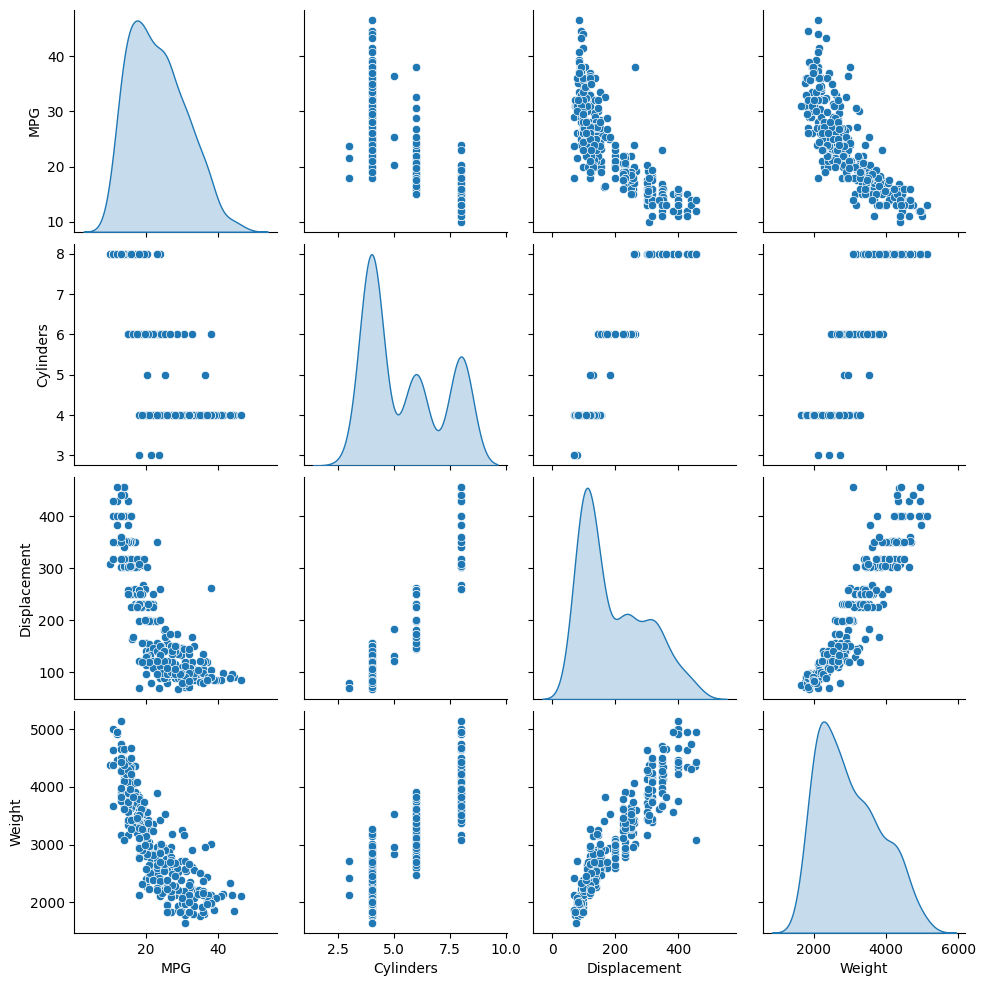

In [6]:
# Парный график (scatter plot) для визуальной оценки корреляций
# diag_kind='kde' - рисует график плотности распределения на диагонали вместо гистограммы
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')
plt.show()

Также посмотрим на статистические показатели нащих полей.

In [8]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0
Europe,314.0,0.178344,0.383413,0.0,0.00,0.0,0.00,1.0
Japan,314.0,0.197452,0.398712,0.0,0.00,0.0,0.00,1.0
USA,314.0,0.624204,0.485101,0.0,0.00,1.0,1.00,1.0


## 5. Отделение признаков от целевой переменной

Теперь нам нужно отделить то, что мы будем предсказывать (MPG), от того, на основе чего мы предсказываем (все остальные колонки). Это называется выделением признаков (features) и меток (labels). Мы используем метод pop, который извлекает колонку MPG из датафрейма, и возвращает ее как отдельную серию, удаляя из исходного набора признаков.

Модель должна получать на вход признаки, а целевое значение `MPG` предсказывать.

In [7]:
# Создаем копии для тренировочных и тестовых признаков
train_features = train_dataset.copy()
test_features = test_dataset.copy()

# Метод .pop() извлекает колонку 'MPG' в отдельную переменную (train_labels) и удаляет её из train_features
train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

print("Признаки train:", train_features.shape)
print("Целевая переменная train:", train_labels.shape)

Признаки train: (314, 9)
Целевая переменная train: (314,)


## 6. Нормализация признаков

 Признак Weight измеряется тысячами, а Model Year — десятками. Если подать такие разнородные данные в сеть, градиенты будут нестабильны, и обучение займет много времени. Мы используем слой tf.keras.layers.Normalization. Это часть препроцессинга внутри самой модели. Сначала мы вызываем метод adapt(), который вычисляет среднее и дисперсию по всей тренировочной выборке и запоминает их. Затем, при вызове слоя, он будет применять формулу (x - mean) / std, приводя все признаки к одному масштабу с нулевым средним и единичной дисперсией.

In [ ]:
train_features.describe().transpose()[['mean', 'std']]

,mean,std
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642
Europe,0.178344,0.383413
Japan,0.197452,0.398712
USA,0.624204,0.485101


In [9]:
# Создаем слой нормализации. axis=-1 означает нормализацию по последней оси (по столбцам-признакам)
normalizer = tf.keras.layers.Normalization(axis=-1)
# "Обучаем" (адаптируем) слой на тренировочных данных. Он вычисляет среднее и дисперсию.
normalizer.adapt(np.array(train_features))

# Проверяем, какие средние значения вычислил слой для каждого из признаков
print("Средние значения после адаптации слоя:")
print(normalizer.mean.numpy())

Средние значения после адаптации слоя:
[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]


Проверим, как слой нормализации преобразует одну строку данных.

In [10]:
first = np.array(train_features[:1])

with np.printoptions(precision=2, suppress=True):
    print("Первый объект:")
    print(first)
    print()
    print("После нормализации:")
    print(normalizer(first).numpy())

Первый объект:
[[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]

После нормализации:
[[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


## 7. Линейная модель по одному признаку

Сначала мы строим простую линейную регрессию, используя только признак Horsepower (лошадиные силы). Это базовая модель для сравнения. Модель Sequential состоит всего из двух слоев: нормализация и один полносвязный слой Dense(units=1). units=1 означает, что на выходе одно число — предсказанный MPG. Компилируем с оптимизатором Adam и функцией потерь MAE. Обучаем 100 эпох, сохраняя историю в переменную history, чтобы потом построить график.

In [11]:
# Подготовка данных: выделяем признак Horsepower как numpy массив
horsepower = np.array(train_features['Horsepower'])

# Создаем отдельный слой нормализации для одного признака
# input_shape=[1,] - у нас на входе одно число
horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)

# Строим Sequential модель
horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

# Выводим архитектуру модели и количество параметров (всего 2: w и b)
horsepower_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

In [12]:
# Компиляция модели.
# optimizer='Adam' - адаптивный градиентный спуск
# loss='mean_absolute_error' - метрика ошибки MAE
horsepower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

Обучаю модель и сохраняю историю ошибки по эпохам.

In [14]:
# Обучение модели.
%%time
history = horsepower_model.fit(
    train_features['Horsepower'], # X
    train_labels,                 # Y
    epochs=100,                   # Количество проходов по всем данным
    verbose=0,                    # Не печатать логи каждой эпохи
    validation_split = 0.2)       # 20% тренировочных данных использовать для валидации

CPU times: user 14 s, sys: 577 ms, total: 14.6 s
Wall time: 16.8 s


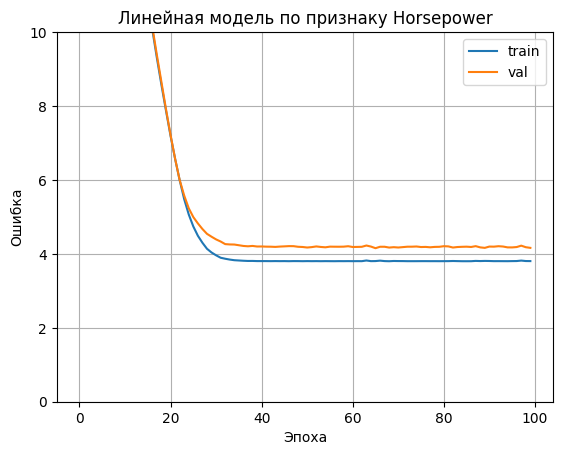

In [15]:
def plot_loss(history, title):
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.ylim([0, 10])
    plt.xlabel('Эпоха')
    plt.ylabel('Ошибка')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss(history, 'Линейная модель по признаку Horsepower')

### Линейная модель по одному признаку (Horsepower)
График ошибки:

Ошибка быстро уменьшается в начале и стабилизируется;
train и val близки → переобучения нет;
но ошибка довольно высокая (~4).


Посмотрим, как простая линейная модель описывает зависимость `MPG` от `Horsepower`.

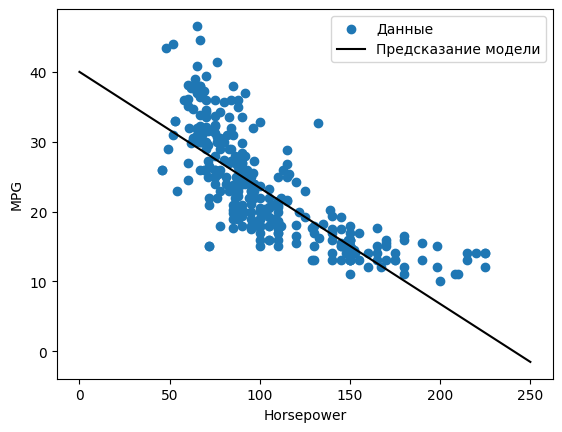

In [ ]:
x = tf.linspace(0.0, 250, 251)
y = horsepower_model.predict(x, verbose=0)

plt.scatter(train_features['Horsepower'], train_labels, label='Данные')
plt.plot(x, y, color='black', label='Предсказание модели')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.show()

График зависимости:
видим линейную зависимость: чем больше мощность, тем меньше MPG;
но точки сильно разбросаны → одного признака недостаточно.

Вывод: модель слишком простая, плохо описывает данные.

## 8. Линейная модель по всем признакам

Теперь создадим линейную модель сразу по всем признакам, она должна показывать лучшие результаты.

In [16]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error'
)

linear_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (314, 9)               │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

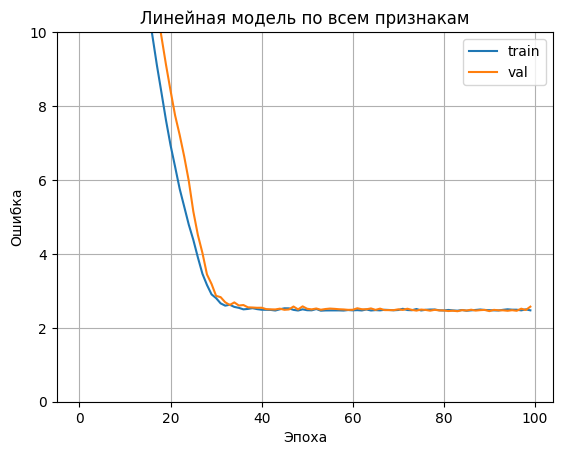

CPU times: user 13.1 s, sys: 510 ms, total: 13.6 s
Wall time: 13.9 s


In [17]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=0,
    validation_split=0.2
)

plot_loss(history, 'Линейная модель по всем признакам')

Линейная модель по всем признакам

ошибка заметно ниже (~2.5);
train и val почти совпадают → модель обобщает хорошо;
обучение быстро сходится.

Вывод: добавление признаков сильно улучшило качество.

## 9. Нейронная сеть для регрессии

Теперь строю более мощную модель — полносвязную нейронную сеть.  
У неё два скрытых слоя, поэтому она может находить более сложные зависимости в данных.

Линейная модель не может уловить сложные нелинейные зависимости, например, влияние веса на расход топлива. Поэтому мы строим глубокую нейронную сеть. Мы создаем функцию build_and_compile_model. Внутри модели добавляются два скрытых слоя Dense с 64 нейронами и функцией активации relu. ReLU вносит нелинейность, позволяя сети аппроксимировать сложные функции. Скорость обучения (learning_rate) снижена до 0.001 по сравнению с линейной моделью, так как глубокая сеть более чувствительна к большим шагам оптимизации

In [18]:
def build_and_compile_model(norm):
    model = keras.Sequential([
      norm,                            # Слой нормализации входных данных
      layers.Dense(64, activation='relu'), # Первый скрытый слой (64 нейрона, ReLU)
      layers.Dense(64, activation='relu'), # Второй скрытый слой (64 нейрона, ReLU)
      layers.Dense(1)                  # Выходной слой (линейный, 1 значение MPG)
    ])

    # Компилируем модель
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='mean_absolute_error'
    )
    return model

Сначала обучу нейросеть только по одному признаку `Horsepower`, чтобы сравнить её с простой линейной моделью.

In [19]:
dnn_horsepower_model = build_and_compile_model(horsepower_normalizer)
dnn_horsepower_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356 (17.02 KB)

 Trainable params: 4,353 (17.00 KB)

 Non-trainable params: 3 (16.00 B)

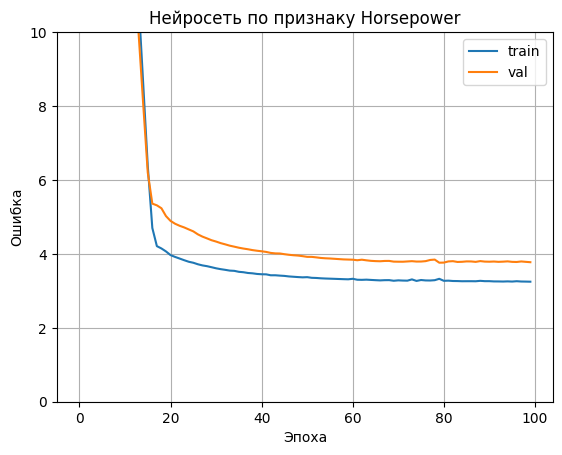

CPU times: user 15.4 s, sys: 544 ms, total: 15.9 s
Wall time: 22.3 s


In [20]:
%%time
history = dnn_horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)

plot_loss(history, 'Нейросеть по признаку Horsepower')

Нейросеть по одному признаку

ошибка немного ниже, чем у линейной модели по одному признаку;
но всё равно остаётся высокой (~3.5–4);
переобучения нет (кривые близки).

Вывод: даже нейросеть не помогает, если мало признаков

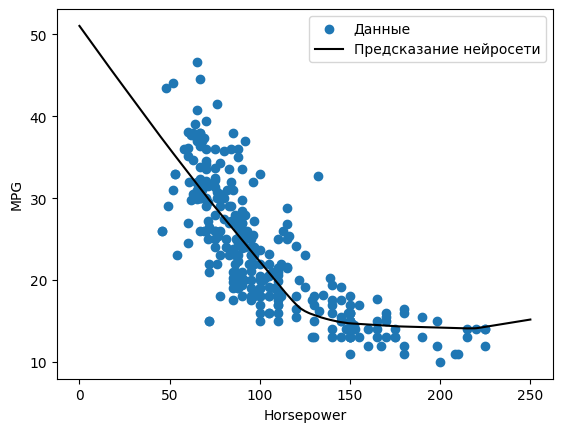

In [ ]:
x = tf.linspace(0.0, 250, 251)
y = dnn_horsepower_model.predict(x, verbose=0)

plt.scatter(train_features['Horsepower'], train_labels, label='Данные')
plt.plot(x, y, color='black', label='Предсказание нейросети')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend()
plt.show()

## 10. Итоговая нейросеть по всем признакам

Это основная модель для задания, потому что она использует все признаки автомобиля.

In [21]:
# Создаем модель, передавая ранее созданный normalizer для всех 9 признаков
dnn_model = build_and_compile_model(normalizer)
dnn_model.summary() # Видим, что количество параметров значительно выросло (~4.5k)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

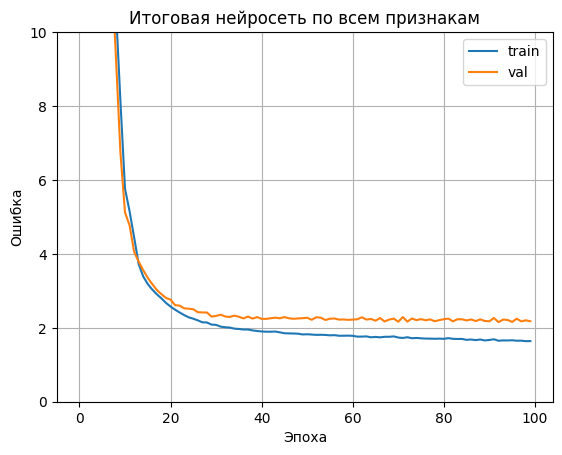

CPU times: user 15.9 s, sys: 639 ms, total: 16.6 s
Wall time: 16.7 s


In [22]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=0,
    epochs=100
)

plot_loss(history, 'Итоговая нейросеть по всем признакам')

Итоговая нейросеть по всем признакам

самая низкая ошибка (~1.7–2);
train чуть ниже val → лёгкое переобучение, но норм;
модель стабильно обучилась.

Вывод: это лучшая модель из всех.

## 11. Оценка качества модели

По условию задания нужно оценить качество по двум метрикам:
- **MSE** — среднеквадратическая ошибка (Мы берём модуль разницы между реальным значением и предсказанием, суммируем все ошибки и делим на количество примеров. Все ошибки влияют одинаково, независимо от их величины)
- **MAE** — средняя абсолютная ошибка (Мы берём квадрат разницы между реальным значением и предсказанием, большие ошибки штрафуются гораздо сильнее (из-за возведения в квадрат))

MAE дополнительно считаю через `tf.losses.MeanAbsoluteError()`

In [23]:
# Получаем предсказания модели и преобразуем в одномерный массив
test_predictions = dnn_model.predict(test_features, verbose=0).flatten()

# Вычисляем MSE (среднеквадратичную ошибку)
mse_metric = tf.keras.metrics.MeanSquaredError()
mse = mse_metric(test_labels, test_predictions).numpy()

# Вычисляем MAE (среднюю абсолютную ошибку)
mae_loss = tf.losses.MeanAbsoluteError()
mae = mae_loss(test_labels, test_predictions).numpy()

# Выводим результаты
print(f"MSE на тестовой выборке: {mse:.4f}")
print(f"MAE на тестовой выборке: {mae:.4f}")

MSE на тестовой выборке: 5.2108
MAE на тестовой выборке: 1.6841


Метрики

* MSE ≈ 5.39
* MAE ≈ 1.75

Интерпретация:
в среднем ошибка прогноза ≈ 1.75 MPG — это достаточно хорошее качество.

Для сравнения покажу качество и других моделей по MAE.  
Но основной вывод по заданию делаю именно для итоговой нейросети `dnn_model`.

In [24]:
# Создаём пустой словарь для хранения результатов всех моделей
test_results = {}

# Линейная регрессия только по лошадиным силам (Horsepower)
test_results['Линейная модель (1 признак)'] = horsepower_model.evaluate(
    test_features['Horsepower'], test_labels, verbose=0
)

# Линейная регрессия по всем 9 признакам
test_results['Линейная модель (все признаки)'] = linear_model.evaluate(
    test_features, test_labels, verbose=0
)

# Нейронная сеть только по лошадиным силам
test_results['Нейросеть (1 признак)'] = dnn_horsepower_model.evaluate(
    test_features['Horsepower'], test_labels, verbose=0
)

# Нейронная сеть по всем признакам
test_results['Нейросеть (все признаки)'] = dnn_model.evaluate(
    test_features, test_labels, verbose=0
)

# Создаём красивую таблицу: модели в строках, метрика MAE в столбце
pd.DataFrame(test_results, index=['MAE']).T

,MAE
Линейная модель (1 признак),3.637482
Линейная модель (все признаки),2.585151
Нейросеть (1 признак),2.912037
Нейросеть (все признаки),1.684134


Построю график: по горизонтали — истинные значения, по вертикали — предсказания модели.  
Если модель хорошая, точки должны лежать близко к диагонали.

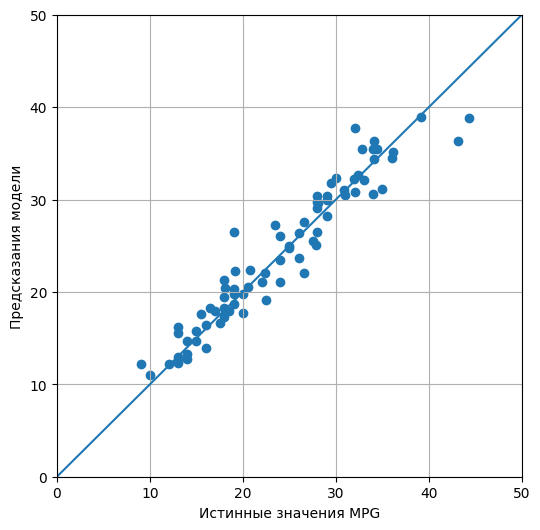

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(test_labels, test_predictions)
plt.xlabel('Истинные значения MPG')
plt.ylabel('Предсказания модели')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims)
plt.grid(True)
plt.show()

Также посмотрю на ошибки предсказаний.

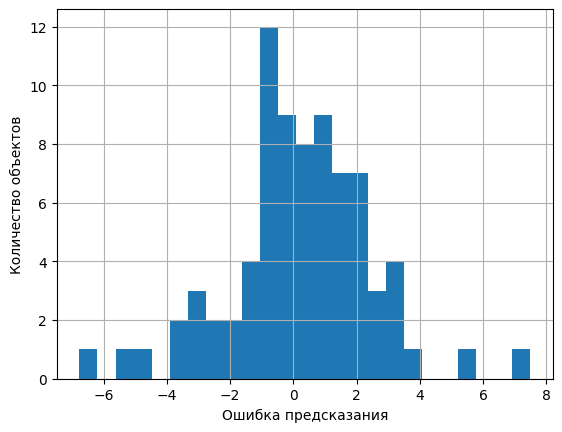

In [26]:
error = test_predictions - test_labels

plt.hist(error, bins=25)
plt.xlabel('Ошибка предсказания')
plt.ylabel('Количество объектов')
plt.grid(True)
plt.show()

Гистограмма ошибок

* ошибки распределены вокруг 0 → модель не даёт систематического смещения;
* большинство ошибок в диапазоне примерно [-3, 3];
* есть редкие большие ошибки (выбросы).

Вывод: модель в целом предсказывает корректно, но есть отдельные неточные случаи.

## 12. Сохранение модели

После обучения модель можно сохранить, чтобы потом использовать без повторного обучения.

In [27]:
dnn_model.save('dnn_model.keras')

In [28]:
reloaded = tf.keras.models.load_model('dnn_model.keras')

reloaded_predictions = reloaded.predict(test_features, verbose=0).flatten()

reloaded_mse = tf.keras.metrics.MeanSquaredError()(test_labels, reloaded_predictions).numpy()
reloaded_mae = tf.losses.MeanAbsoluteError()(test_labels, reloaded_predictions).numpy()

print(f"MSE после загрузки модели: {reloaded_mse:.4f}")
print(f"MAE после загрузки модели: {reloaded_mae:.4f}")

MSE после загрузки модели: 5.2108
MAE после загрузки модели: 1.6841


## Вывод

В этой работе я обучила несколько моделей для задачи регрессии на датасете Auto MPG и сравнила их между собой.

Лучший и наиболее осмысленный вариант для этой задачи — нейронная сеть по всем признакам (`dnn_model`), потому что она использует полную информацию об автомобиле и умеет находить нелинейные зависимости.

Качество итоговой модели я оценила по двум метрикам:
- **MSE** — среднеквадратическая ошибка;
- **MAE** — средняя абсолютная ошибка.

Таким образом, задание на обучение нейронной сети для прогнозирования топливной экономичности автомобилей выполнено.